# HGT — Heterogeneous Graph Transformer for Hackathon Team Recommendation

In [1]:
import json
import time
import copy
import itertools
import numpy as np
import pandas as pd
import torch
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
import sys, random
from pathlib import Path
from torch_geometric.data import HeteroData
from torch_geometric.loader import DataLoader as PyGDataLoader
from models.recommenders import (
    TeamCompletionHGT,
    TeamCompletionSAGE,
    TeamCompletionRF,
    participant_features,
    hackathon_features,
    team_features,
    PARTICIPANT_DIM,
)
from entities.skills import SKILL_TO_IDX, ALL_SKILLS, N_SKILLS
from entities.positions import POSITION_TO_IDX, N_POSITIONS

In [2]:
OUTPUT_DIR = Path("output")
DATA_DIR = Path("output/data")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sys.path.insert(0, str(OUTPUT_DIR.parent.parent))
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
def _sync():
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

## 1. Load and transform CSV data

In [4]:
df_skills = pd.read_csv(DATA_DIR / "skills.csv")
df_positions = pd.read_csv(DATA_DIR / "positions.csv")
df_hackathons = pd.read_csv(DATA_DIR / "hackathons.csv")
df_participants = pd.read_csv(DATA_DIR / "participants.csv")
df_participants["skills_vec"] = df_participants["skills_vector"].apply(json.loads)
df_team_part = pd.read_csv(DATA_DIR / "team_participants.csv")

In [5]:
SKILL_TO_IDX = {row.skill_name: row.skill_id for _, row in df_skills.iterrows()}
POSITION_IDX = {row.position_name: row.position_id for _, row in df_positions.iterrows()}
TOPICS = sorted(df_hackathons["topic"].unique().tolist())
TOPIC_IDX = {t: i for i, t in enumerate(TOPICS)}

N_SKILLS = len(SKILL_TO_IDX)
N_POSITIONS = len(POSITION_IDX)
N_TOPICS = len(TOPICS)

### Team preparation

In [6]:
UNRANKED_DOWNSAMPLE_RATE = 1
K_AUGMENTS = 15
MAX_RANK = 3

In [7]:
def _team_agg(g):
    return pd.Series({
        "avg_experience": g["experience_years"].mean(),
    })

In [8]:
def _placement_weight(place_rank: int) -> float:
    if place_rank <= MAX_RANK:
        return 1.0 - (place_rank - 1) * 0.1
    return 0.5

In [9]:
df_teams = (
    df_team_part
    .groupby(["team_id", "hackathon_id"], sort=True)
    .agg(
        team_size=("participant_id", "count"),
        place=("place", "first"),
        place_rank=("place_rank", "first"),
    )
    .reset_index()
)
print(f"Teams: {len(df_teams)}")
df_teams.head()

Teams: 10213


,team_id,hackathon_id,team_size,place,place_rank
0,0,0,3,participant,4
1,1,0,3,participant,4
2,2,0,4,participant,4
3,3,0,4,participant,4
4,4,0,2,participant,4


In [10]:
part_cols = df_participants[["participant_id", "experience_years", "position", "skills_vec"]].copy()
merged = df_team_part.merge(part_cols, on="participant_id")

team_stats = merged.groupby("team_id").apply(_team_agg).reset_index()
df_teams = df_teams.merge(team_stats, on="team_id").sort_values("team_id").reset_index(drop=True)

rng = np.random.default_rng(42)
unranked_mask = df_teams["place_rank"] > MAX_RANK
unranked_idx = df_teams.index[unranked_mask]
keep_unranked = rng.choice(unranked_idx, size=int(len(unranked_idx) * UNRANKED_DOWNSAMPLE_RATE), replace=False)
keep_mask = ~unranked_mask | df_teams.index.isin(keep_unranked)
df_teams = df_teams[keep_mask].reset_index(drop=True)

kept_team_ids = set(df_teams["team_id"])
df_team_part = df_team_part[df_team_part["team_id"].isin(kept_team_ids)].reset_index(drop=True)
merged = merged[merged["team_id"].isin(kept_team_ids)].reset_index(drop=True)

print(f"Teams after downsampling: {len(df_teams)}  "
      f"(ranked: {(df_teams['place_rank'] <= MAX_RANK).sum()}, "
      f"unranked: {(df_teams['place_rank'] > MAX_RANK).sum()})")

x_team_raw = df_teams[["team_size", "avg_experience"]].values.astype(np.float32)
x_team = x_team_raw.copy()
x_team[:, 0] /= x_team[:, 0].max()
x_team[:, 1] /= x_team[:, 1].max()

y_team = torch.tensor(df_teams["place_rank"].values - 1, dtype=torch.long)

print(f"x_team        : {x_team.shape}")
print(f"y_team classes: {y_team.unique().tolist()}")
df_teams.head()

Teams after downsampling: 10213  (ranked: 900, unranked: 9313)
x_team        : (10213, 2)
y_team classes: [0, 1, 2, 3]


,team_id,hackathon_id,team_size,place,place_rank,avg_experience
0,0,0,3,participant,4,4.000000
1,1,0,3,participant,4,3.466667
2,2,0,4,participant,4,1.275000
3,3,0,4,participant,4,1.925000
4,4,0,2,participant,4,3.800000


## 2. Heterogeneous Graph building

In [11]:
part_id_map = {int(pid): i for i, pid in enumerate(df_participants["participant_id"])}
team_id_map = {int(tid): i for i, tid in enumerate(df_teams["team_id"])}
hack_id_map = {int(hid): i for i, hid in enumerate(df_hackathons["hackathon_id"])}

src_p, dst_s = [], []
for _, row in df_participants.iterrows():
    pid = part_id_map[int(row["participant_id"])]
    for sid, has in enumerate(row["skills_vec"]):
        if has > 0:
            src_p.append(pid)
            dst_s.append(sid)
ei_has_skill = torch.tensor([src_p, dst_s], dtype=torch.long)

src_mem = [part_id_map[int(p)] for p in df_team_part["participant_id"]]
dst_mem = [team_id_map[int(t)] for t in df_team_part["team_id"]]
ei_member_of = torch.tensor([src_mem, dst_mem], dtype=torch.long)

src_team = [team_id_map[int(t)] for t in df_teams["team_id"]]
dst_hack = [hack_id_map[int(h)] for h in df_teams["hackathon_id"]]
ei_participated_in = torch.tensor([src_team, dst_hack], dtype=torch.long)

src_ht = list(range(len(df_hackathons)))
dst_topic = [TOPIC_IDX[row["topic"]] for _, row in df_hackathons.iterrows()]
ei_hack_topic = torch.tensor([src_ht, dst_topic], dtype=torch.long)

print(f"(participant, has_skill,       skill)    : {ei_has_skill.shape}")
print(f"(participant, member_of,       team)     : {ei_member_of.shape}")
print(f"(team,        participated_in, hackathon): {ei_participated_in.shape}")
print(f"(hackathon,   has_topic,        topic)   : {ei_hack_topic.shape}")

(participant, has_skill,       skill)    : torch.Size([2, 170212])
(participant, member_of,       team)     : torch.Size([2, 38471])
(team,        participated_in, hackathon): torch.Size([2, 10213])
(hackathon,   has_topic,        topic)   : torch.Size([2, 300])


In [12]:
x_participant = np.stack([
    participant_features(row["position"], row["skills_vec"] if isinstance(row["skills_vec"], list) else
    [ALL_SKILLS[i] for i, v in enumerate(row["skills_vec"]) if v > 0],
                         row["experience_years"])
    for _, row in df_participants.iterrows()
])

x_skill = np.eye(N_SKILLS, dtype=np.float32)
_x_skill_cpu = torch.tensor(x_skill, dtype=torch.float)

x_topic = np.eye(N_TOPICS, dtype=np.float32)
_x_topic_cpu = torch.tensor(x_topic, dtype=torch.float)

x_hackathon = np.stack([
    hackathon_features(row["topic"], int(row["max_team_size"]))
    for _, row in df_hackathons.iterrows()
])

In [13]:
data = HeteroData()

data["participant"].x = torch.tensor(x_participant, dtype=torch.float)
data["skill"].x = torch.tensor(x_skill, dtype=torch.float)
data["topic"].x = torch.tensor(x_topic, dtype=torch.float)
data["hackathon"].x = torch.tensor(x_hackathon, dtype=torch.float)
data["team"].x = torch.tensor(x_team, dtype=torch.float)
data["team"].y = y_team

data["participant", "has_skill", "skill"].edge_index = ei_has_skill
data["participant", "member_of", "team"].edge_index = ei_member_of
data["team", "participated_in", "hackathon"].edge_index = ei_participated_in
data["hackathon", "has_topic", "topic"].edge_index = ei_hack_topic

data["skill", "skill_of", "participant"].edge_index = ei_has_skill.flip(0)
data["team", "has_member", "participant"].edge_index = ei_member_of.flip(0)
data["hackathon", "hosts", "team"].edge_index = ei_participated_in.flip(0)
data["topic", "topic_of", "hackathon"].edge_index = ei_hack_topic.flip(0)

data = data.to(DEVICE)
print(data)

HeteroData(
  participant={ x=[38471, 101] },
  skill={ x=[85, 85] },
  topic={ x=[10, 10] },
  hackathon={ x=[300, 1] },
  team={
    x=[10213, 2],
    y=[10213],
  },
  (participant, has_skill, skill)={ edge_index=[2, 170212] },
  (participant, member_of, team)={ edge_index=[2, 38471] },
  (team, participated_in, hackathon)={ edge_index=[2, 10213] },
  (hackathon, has_topic, topic)={ edge_index=[2, 300] },
  (skill, skill_of, participant)={ edge_index=[2, 170212] },
  (team, has_member, participant)={ edge_index=[2, 38471] },
  (hackathon, hosts, team)={ edge_index=[2, 10213] },
  (topic, topic_of, hackathon)={ edge_index=[2, 300] }
)


In [14]:
print("Node counts:")
for ntype in data.node_types:
    print(f"\t{ntype:12s} {data[ntype].x.shape}")

print("\nEdge counts:")
for etype in data.edge_types:
    ei = data[etype].edge_index
    print(f"\t{str(etype):40s} {ei.shape[1]:>6} edges")

print("\nLabel distribution (team placement)")
labels = ["1st", "2nd", "3rd", "participant"]
for i, lbl in enumerate(labels):
    n = (y_team == i).sum().item()
    print(f"\t{lbl:12s} ({100 * n / len(y_team):.1f}%)")

Node counts:
	participant  torch.Size([38471, 101])
	skill        torch.Size([85, 85])
	topic        torch.Size([10, 10])
	hackathon    torch.Size([300, 1])
	team         torch.Size([10213, 2])

Edge counts:
	('participant', 'has_skill', 'skill')    170212 edges
	('participant', 'member_of', 'team')      38471 edges
	('team', 'participated_in', 'hackathon')  10213 edges
	('hackathon', 'has_topic', 'topic')         300 edges
	('skill', 'skill_of', 'participant')     170212 edges
	('team', 'has_member', 'participant')     38471 edges
	('hackathon', 'hosts', 'team')            10213 edges
	('topic', 'topic_of', 'hackathon')          300 edges

Label distribution (team placement)
	1st          (2.9%)
	2nd          (2.9%)
	3rd          (2.9%)
	participant  (91.2%)


In [15]:
assert ei_has_skill[0].max() < len(df_participants)
assert ei_has_skill[1].max() < N_SKILLS
assert ei_member_of[0].max() < len(df_participants)
assert ei_member_of[1].max() < len(df_teams)
assert ei_participated_in[0].max() < len(df_teams)
assert ei_participated_in[1].max() < len(df_hackathons)
print("\nAll edge index checks passed")


All edge index checks passed


In [16]:
member_lookup: dict[int, list[dict]] = {}
for tid, group in merged.groupby("team_id"):
    member_lookup[int(tid)] = [
        {
            "experience_years": float(row["experience_years"]),
            "position": row["position"],
            "skills": [ALL_SKILLS[i] for i, v in enumerate(row["skills_vec"]) if v > 0],
        }
        for _, row in group.iterrows()
    ]

hack_lookup: dict[int, dict] = {
    int(row["hackathon_id"]): {
        "topic": row["topic"],
        "max_team_size": int(row["max_team_size"]),
    }
    for _, row in df_hackathons.iterrows()
}

sample_tid = next(iter(member_lookup))
print(f"Teams in lookup: {len(member_lookup)}")
print(f"Sample team {sample_tid}: {member_lookup[sample_tid]}")

Teams in lookup: 10213
Sample team 0: [{'experience_years': 1.2, 'position': 'Blockchain Developer', 'skills': ['Python', 'C++', 'MySQL', 'CI/CD', 'NumPy', 'Prototyping']}, {'experience_years': 7.5, 'position': 'Data Scientist', 'skills': ['AWS', 'CI/CD', 'TensorFlow', 'scikit-learn', 'NumPy']}, {'experience_years': 3.3, 'position': 'Full Stack Developer', 'skills': ['Python', 'Redis', 'Docker', 'CI/CD', 'TensorFlow', 'System Design']}]


In [17]:
topic_skill_freq: dict[str, torch.Tensor] = {}
for _topic in TOPICS:
    _freq = torch.zeros(N_SKILLS, dtype=torch.float)
    _total_w = 0.0
    for _row in df_teams.itertuples():
        _hid = int(_row.hackathon_id)
        if hack_lookup[_hid]["topic"] != _topic:
            continue
        _w = _placement_weight(int(_row.place_rank))
        _total_w += _w
        for _m in member_lookup.get(int(_row.team_id), []):
            for _s in _m["skills"]:
                _sid = SKILL_TO_IDX.get(_s)
                if _sid is not None:
                    _freq[_sid] += _w
    topic_skill_freq[_topic] = (_freq / max(_total_w, 1e-6)).clamp(0.0, 1.0)

### Graph Visualization

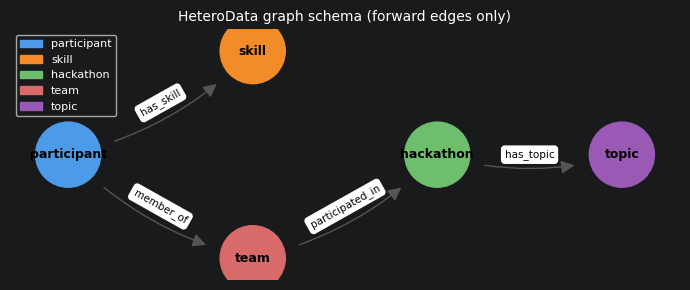

In [18]:
G_schema = nx.DiGraph()
node_colors = {
    "participant": "#4C9BE8",
    "skill": "#F28C28",
    "hackathon": "#6DBF6D",
    "team": "#D96A6A",
    "topic": "#9B59B6",
}
for ntype in data.node_types:
    G_schema.add_node(ntype)

for src_type, rel, dst_type in data.edge_types:
    if (not rel.startswith("skill_of") and not rel.startswith("has_member")
            and not rel.startswith("hosts") and not rel.startswith("topic_of")):
        G_schema.add_edge(src_type, dst_type, label=rel)

pos = {"participant": (0, 0.5), "skill": (1, 1), "team": (1, 0), "hackathon": (2, 0.5), "topic": (3, 0.5)}

fig, ax = plt.subplots(figsize=(7, 3))
nx.draw_networkx_nodes(G_schema, pos, node_size=2200,
                       node_color=[node_colors[n] for n in G_schema.nodes()], ax=ax)
nx.draw_networkx_labels(G_schema, pos, font_size=9, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G_schema, pos, ax=ax, arrows=True,
                       arrowstyle="-|>", arrowsize=20, edge_color="#555",
                       connectionstyle="arc3,rad=0.15", min_source_margin=35, min_target_margin=35)
edge_labels = {(u, v): d["label"] for u, v, d in G_schema.edges(data=True)}
nx.draw_networkx_edge_labels(G_schema, pos, edge_labels, font_size=7.5, ax=ax)
patches = [mpatches.Patch(color=c, label=n) for n, c in node_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8)
ax.set_title("HeteroData graph schema (forward edges only)", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

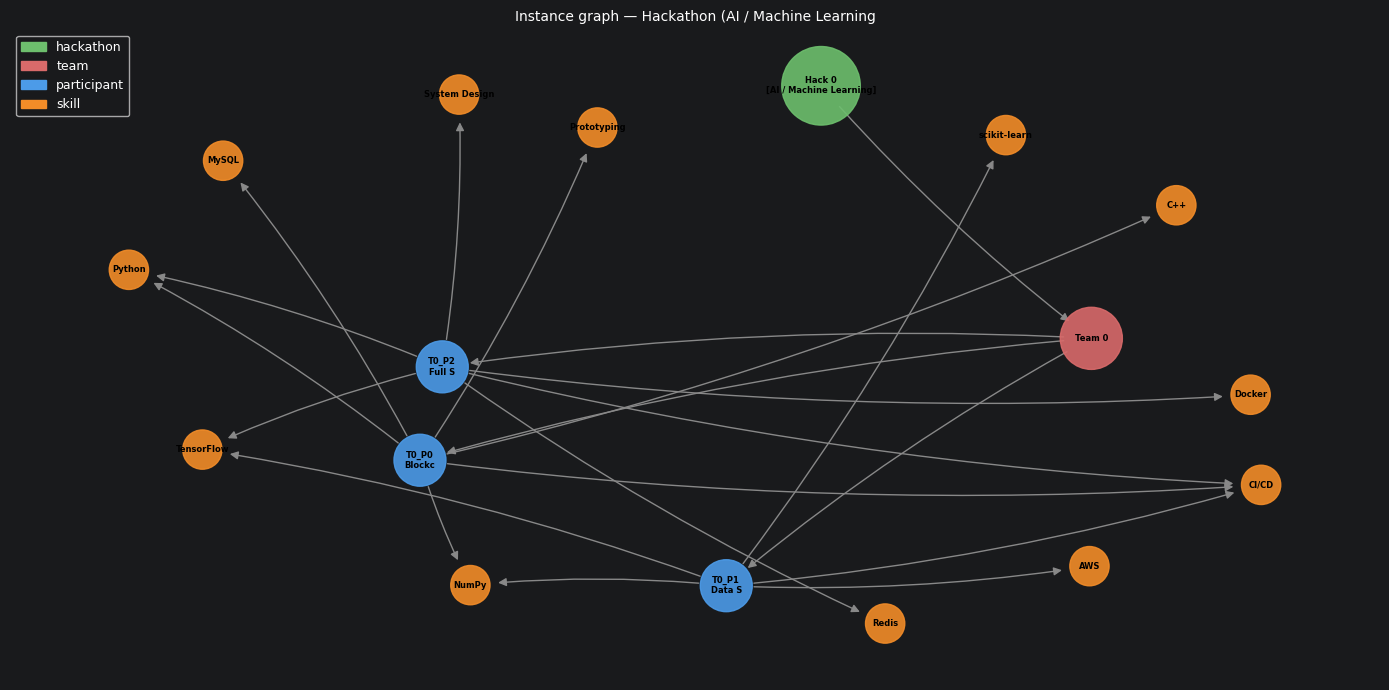

In [19]:
EXAMPLE_HACK_ID = int(df_hackathons["hackathon_id"].iloc[0])
hack_info = hack_lookup[EXAMPLE_HACK_ID]
hack_team = df_teams[df_teams["hackathon_id"] == EXAMPLE_HACK_ID]["team_id"].iloc[0]

G_inst = nx.DiGraph()
h_node = f"Hack {EXAMPLE_HACK_ID}\n[{hack_info['topic']}]"
G_inst.add_node(h_node, ntype="hackathon")

t_node = f"Team {hack_team}"
G_inst.add_node(t_node, ntype="team")
G_inst.add_edge(h_node, t_node)
for idx, member in enumerate(member_lookup.get(hack_team, [])):
    p_node = f"T{hack_team}_P{idx}\n{member['position'][:6]}"
    G_inst.add_node(p_node, ntype="participant")
    G_inst.add_edge(t_node, p_node)
    for skill in member["skills"]:
        G_inst.add_node(skill, ntype="skill")
        G_inst.add_edge(p_node, skill)

_inst_colors = {"hackathon": "#6DBF6D", "team": "#D96A6A",
                "participant": "#4C9BE8", "skill": "#F28C28"}
node_colors_inst = [_inst_colors[G_inst.nodes[n]["ntype"]] for n in G_inst.nodes()]
node_sizes_inst = [
    3200 if G_inst.nodes[n]["ntype"] == "hackathon"
    else 2000 if G_inst.nodes[n]["ntype"] == "team"
    else 1400 if G_inst.nodes[n]["ntype"] == "participant"
    else 800 for n in G_inst.nodes()
]

pos_inst = nx.spring_layout(G_inst, seed=42, k=2.2)

fig, ax = plt.subplots(figsize=(14, 7))
nx.draw_networkx_nodes(G_inst, pos_inst, node_color=node_colors_inst,
                       node_size=node_sizes_inst, alpha=0.9, ax=ax)
nx.draw_networkx_labels(G_inst, pos_inst, font_size=6, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G_inst, pos_inst, ax=ax, arrows=True,
                       arrowstyle="-|>", arrowsize=12, edge_color="#888",
                       connectionstyle="arc3,rad=0.05",
                       min_source_margin=20, min_target_margin=20)
patches = [mpatches.Patch(color=c, label=n) for n, c in _inst_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=9)
ax.set_title(
    f"Instance graph — Hackathon ({hack_info['topic']}",
    fontsize=10,
)
ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Dataset Preparation

Converted teams into multiple `HeteroData` graph samples via random augmentation: the team members are split into a *partial* (known) set and a *missing* set, and the model is trained to predict the skills and positions contributed by the missing members.

In [20]:
BATCH_SIZE = 128

In [21]:
def _make_sample(hack, partial, missing, place_rank: int) -> HeteroData:
    if partial:
        x_p = torch.tensor(
            np.stack([participant_features(
                m.get("position", ""), m.get("skills", []), m.get("experience_years", 0.0)
            ) for m in partial]),
            dtype=torch.float,
        )
    else:
        x_p = torch.zeros((1, PARTICIPANT_DIM), dtype=torch.float)

    x_h = torch.tensor(hackathon_features(hack["topic"], hack["max_team_size"]), dtype=torch.float).unsqueeze(0)
    x_t = torch.tensor(team_features(partial, hack["max_team_size"]), dtype=torch.float).unsqueeze(0)

    src_p, dst_s = [], []
    for pid, m in enumerate(partial):
        for s in m.get("skills", []):
            if s in SKILL_TO_IDX:
                src_p.append(pid)
                dst_s.append(SKILL_TO_IDX[s])
    ei_hs = (
        torch.tensor([src_p, dst_s], dtype=torch.long) if src_p
        else torch.zeros((2, 0), dtype=torch.long)
    )
    ei_mo = (
        torch.tensor([list(range(len(partial))), [0] * len(partial)], dtype=torch.long)
        if partial else torch.zeros((2, 0), dtype=torch.long)
    )

    sk_tgt = torch.zeros(N_SKILLS, dtype=torch.float)
    po_tgt = torch.zeros(N_POSITIONS, dtype=torch.float)
    for m in missing:
        for s in m["skills"]:
            sid = SKILL_TO_IDX.get(s)
            if sid is not None:
                sk_tgt[sid] = 1.0
        pid = POSITION_TO_IDX.get(m["position"])
        if pid is not None:
            po_tgt[pid] = 1.0

    sample_weight = _placement_weight(place_rank)

    data = HeteroData()
    data["participant"].x = x_p
    data["skill"].x = _x_skill_cpu
    data["topic"].x = _x_topic_cpu
    data["hackathon"].x = x_h
    data["team"].x = x_t
    data["team"].sk_tgt = sk_tgt.unsqueeze(0)
    data["team"].po_tgt = po_tgt.unsqueeze(0)
    data["team"].sample_weight = torch.tensor([sample_weight], dtype=torch.float)

    ei_part = torch.tensor([[0], [0]], dtype=torch.long)
    t_idx = TOPIC_IDX[hack["topic"]]
    assert 0 <= t_idx < N_TOPICS
    ei_ht = torch.tensor([[0], [t_idx]], dtype=torch.long)

    data["participant", "has_skill", "skill"].edge_index = ei_hs
    data["participant", "member_of", "team"].edge_index = ei_mo
    data["team", "participated_in", "hackathon"].edge_index = ei_part
    data["hackathon", "has_topic", "topic"].edge_index = ei_ht
    data["skill", "skill_of", "participant"].edge_index = ei_hs.flip(0)
    data["team", "has_member", "participant"].edge_index = ei_mo.flip(0)
    data["hackathon", "hosts", "team"].edge_index = ei_part.flip(0)
    data["topic", "topic_of", "hackathon"].edge_index = ei_ht.flip(0)

    return data

In [22]:
def _build_samples(team_id_set, augments):
    samples = []
    for row in df_teams.itertuples():
        tid, hid = int(row.team_id), int(row.hackathon_id)
        if tid not in team_id_set:
            continue
        all_members = member_lookup.get(tid, [])
        hack = hack_lookup[hid]
        if len(all_members) < 2:
            continue
        for _ in range(augments):
            k = random.randint(1, len(all_members) - 1)
            all_indices = list(range(len(all_members)))
            partial_idx = set(random.sample(all_indices, k))
            missing_idx = [i for i in all_indices if i not in partial_idx]
            samples.append(_make_sample(
                hack,
                [all_members[i] for i in partial_idx],
                [all_members[i] for i in missing_idx],
                int(row.place_rank),
            ))
    return samples

In [23]:
print("Pre-building train / validation datasets")

all_team_ids = df_teams["team_id"].tolist()
random.seed(42)
random.shuffle(all_team_ids)
split_idx = int(0.8 * len(all_team_ids))
train_tids = set(all_team_ids[:split_idx])
val_tids = set(all_team_ids[split_idx:])

train_samples = _build_samples(train_tids, K_AUGMENTS)
val_samples = _build_samples(val_tids, K_AUGMENTS)

print(f"Train teams: {len(train_tids):4d} ({len(train_samples):6d} samples)")
print(f"Val teams:\t {len(val_tids):4d} ({len(val_samples):6d} samples)")

Pre-building train / validation datasets
Train teams: 8170 (122550 samples)
Val teams:	 2043 ( 30645 samples)


In [24]:
train_loader = PyGDataLoader(train_samples, batch_size=BATCH_SIZE, shuffle=True)
val_loader = PyGDataLoader(val_samples, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train loader: {len(train_loader)} batches (batch_size={BATCH_SIZE})")
print(f"Val loader:\t {len(val_loader)} batches (batch_size={BATCH_SIZE})")

Train loader: 958 batches (batch_size=128)
Val loader:	 240 batches (batch_size=128)


### 4. Training Loop

In [25]:
HIDDEN_DIM = 128
NUM_EPOCHS = 50
LR = 3e-3
BATCH_SIZE = 256
GRAD_CLIP = 1.0
DROPOUT = 0.25

### Whights assignment

In [26]:
def _per_class_weights(targets: torch.Tensor, max_w: float) -> torch.Tensor:
    pos = targets.sum(dim=0)
    neg = targets.shape[0] - pos
    raw = torch.log1p(neg / (pos + 1e-6))
    lo, hi = raw.min(), raw.max()
    if (hi - lo) < 1e-6:
        return torch.full_like(raw, max_w)
    return 1.0 + (raw - lo) / (hi - lo) * (max_w - 1.0)

In [27]:
_all_sk = torch.stack([s["team"].sk_tgt.squeeze(0) for s in train_samples])
_all_po = torch.stack([s["team"].po_tgt.squeeze(0) for s in train_samples])

SKILLS_POS_WEIGHT_T = _per_class_weights(_all_sk, 5.0).to(DEVICE)
POSITIONS_POS_WEIGHT_T = _per_class_weights(_all_po, 7.0).to(DEVICE)

print(f"{"Skill pos_weight":16s} | min={SKILLS_POS_WEIGHT_T.min():.2f} "
      f"mean={SKILLS_POS_WEIGHT_T.mean():.2f} max={SKILLS_POS_WEIGHT_T.max():.2f}")
print(f"{"Pos pos_weight":16s} | min={POSITIONS_POS_WEIGHT_T.min():.2f} "
      f"mean={POSITIONS_POS_WEIGHT_T.mean():.2f} max={POSITIONS_POS_WEIGHT_T.max():.2f}")

Skill pos_weight | min=1.00 mean=3.98 max=5.00
Pos pos_weight   | min=1.00 mean=4.14 max=7.00


### Metrics

In [28]:
NDCG_K = 6

In [29]:
def _f1_micro(pred: torch.Tensor, tgt: torch.Tensor):
    tp = (pred * tgt).sum()
    fp = (pred * (1 - tgt)).sum()
    fn = ((1 - pred) * tgt).sum()
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    return prec.item(), rec.item(), f1.item()

In [30]:
def _ndcg_at_k(scores: torch.Tensor, tgt: torch.Tensor, k: int = NDCG_K) -> float:
    k = min(k, scores.shape[1])
    top_idx = scores.topk(k, dim=1).indices
    rel = tgt.gather(1, top_idx)
    discounts = 1.0 / torch.log2(
        torch.arange(2, k + 2, dtype=torch.float, device=scores.device)
    )
    dcg = (rel * discounts).sum(dim=1)
    ideal_rel = tgt.sort(dim=1, descending=True).values[:, :k]
    idcg = (ideal_rel * discounts).sum(dim=1)
    ndcg = torch.where(idcg > 0, dcg / idcg, torch.zeros_like(dcg))
    return ndcg.mean().item()

In [31]:
def _mrr(scores: torch.Tensor, tgt: torch.Tensor) -> float:
    has_positive = tgt.sum(dim=1) > 0
    sorted_idx = scores.argsort(dim=1, descending=True)
    sorted_rel = tgt.gather(1, sorted_idx)
    first_hit = sorted_rel.argmax(dim=1).float()
    rr = torch.where(
        has_positive,
        1.0 / (first_hit + 1.0),
        torch.zeros(tgt.shape[0], device=scores.device),
    )
    return rr.mean().item()

### Graph Models Profiling

In [32]:
def profile_model(model, optimizer, name: str, batches=10) -> None:
    _m_sd = copy.deepcopy(model.state_dict())
    _o_sd = copy.deepcopy(optimizer.state_dict())

    t_transfer = t_forward = t_loss = t_backward = t_optim = 0.0

    model.train()
    for batch in itertools.islice(train_loader, batches):
        _sync()
        t0 = time.perf_counter()
        batch = batch.to(DEVICE)
        _sync()
        t_transfer += time.perf_counter() - t0

        _sync()
        t0 = time.perf_counter()
        out = model(batch.x_dict, batch.edge_index_dict)
        _sync()
        t_forward += time.perf_counter() - t0

        _sync()
        t0 = time.perf_counter()
        sk_logits = out["skill_logits"]
        po_logits = out["position_logits"]
        sk_tgt = batch["team"].sk_tgt
        po_tgt = batch["team"].po_tgt

        _pw = SKILLS_POS_WEIGHT_T.unsqueeze(0).expand_as(sk_tgt)
        elem_weight = 1.0 + ((_pw - 1.0) * sk_tgt)
        sk_loss = F.binary_cross_entropy_with_logits(
            sk_logits, sk_tgt,
            weight=elem_weight, reduction="none"
        ).mean(dim=1)

        po_loss = F.binary_cross_entropy_with_logits(
            po_logits, po_tgt,
            pos_weight=POSITIONS_POS_WEIGHT_T, reduction="none"
        ).mean(dim=1)
        loss = (batch["team"].sample_weight * (sk_loss + po_loss)).mean()
        _sync()
        t_loss += time.perf_counter() - t0

        _sync()
        t0 = time.perf_counter()
        optimizer.zero_grad()
        loss.backward()
        _sync()
        t_backward += time.perf_counter() - t0

        _sync()
        t0 = time.perf_counter()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        _sync()
        t_optim += time.perf_counter() - t0

    model.load_state_dict(_m_sd)
    optimizer.load_state_dict(_o_sd)

    n = batches
    times = {
        "batch.to(DEVICE)": t_transfer,
        "forward pass    ": t_forward,
        "loss compute    ": t_loss,
        "backward pass   ": t_backward,
        "optim + clip    ": t_optim,
    }
    total = sum(times.values())

    print(f"{name} per-batch timing over {n} batches  (batch_size={BATCH_SIZE}, device={DEVICE}):")
    for label, t in times.items():
        ms = t / n * 1000
        bar = "-" * int(ms / (total / n * 1000) * 20)
        print(f"  {label} : {ms:7.2f} ms  {bar}")
    print(f" {'─' * 44}")
    total_ms = total / n * 1000
    print(f" total per batch: {total_ms:7.2f} ms")
    total_epoch_s = total_ms * len(train_loader) / 1000
    print(f"\nEstimated full epoch: {total_epoch_s:.1f}s ({total_epoch_s / 60:.2f} min)")
    total_training_m = total_epoch_s * NUM_EPOCHS / 60
    print(f"Estimated {name} training time: {total_training_m:.1f}min ({total_training_m / 60:.2f} h)")

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
        alloc_mb = torch.cuda.memory_allocated(DEVICE) / 1024 ** 2
        reserv_mb = torch.cuda.memory_reserved(DEVICE) / 1024 ** 2
        total_mb = torch.cuda.get_device_properties(DEVICE).total_memory / 1024 ** 2
        util_pct = reserv_mb / total_mb * 100
        print(f"\nGPU memory: allocated={alloc_mb:.0f} MB | "
              f"reserved={reserv_mb:.0f} MB | total={total_mb:.0f} MB  ({util_pct:.1f}% used)\n")
    else:
        print(f"\nRunning on CPU — for GPU profiling use a CUDA-enabled device.")

### Graph Models Training Loop

In [33]:
def train_model(model, optimizer, scheduler, history: dict,
                model_out, ckpt_path, start_epoch: int, name: str,
                early_stopping_patience: int = 5, min_delta: float = 5e-4) -> float:
    best_val_ndcg = 0.0
    best_epoch = -1
    epochs_no_improve = 0

    t_train_start = time.perf_counter()

    for epoch in range(start_epoch, NUM_EPOCHS):
        model.train()
        epoch_loss, n_batches = 0.0, 0
        all_sk_logits, all_sk_tgt = [], []
        all_po_pred, all_po_tgt = [], []

        for batch in train_loader:
            batch = batch.to(DEVICE)
            out = model(batch.x_dict, batch.edge_index_dict)
            skill_logits = out["skill_logits"]
            pos_logits = out["position_logits"]

            sk_tgt = batch["team"].sk_tgt
            po_tgt = batch["team"].po_tgt
            weights = batch["team"].sample_weight

            _pw = SKILLS_POS_WEIGHT_T.unsqueeze(0).expand_as(sk_tgt)
            elem_weight = 1.0 + ((_pw - 1.0) * sk_tgt)
            sk_loss = F.binary_cross_entropy_with_logits(
                skill_logits, sk_tgt, weight=elem_weight, reduction="none"
            ).mean(dim=1)

            po_loss = F.binary_cross_entropy_with_logits(
                pos_logits, po_tgt, pos_weight=POSITIONS_POS_WEIGHT_T, reduction="none"
            ).mean(dim=1)
            loss = (weights * (sk_loss + po_loss)).mean()

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1
            all_sk_logits.append(skill_logits.detach().cpu())
            all_sk_tgt.append(sk_tgt.cpu())
            all_po_pred.append((pos_logits.detach().cpu() > 0).float())
            all_po_tgt.append(po_tgt.cpu())

        train_avg = epoch_loss / max(n_batches, 1)
        _tr_sk_logits = torch.cat(all_sk_logits)
        _tr_sk_tgt = torch.cat(all_sk_tgt)
        tr_sk_p, tr_sk_r, tr_sk_f1 = _f1_micro((_tr_sk_logits > 0).float(), _tr_sk_tgt)
        tr_sk_ndcg = _ndcg_at_k(_tr_sk_logits, _tr_sk_tgt)
        tr_sk_mrr = _mrr(_tr_sk_logits, _tr_sk_tgt)
        tr_po_p, tr_po_r, tr_po_f1 = _f1_micro(torch.cat(all_po_pred), torch.cat(all_po_tgt))

        model.eval()
        val_loss, val_n = 0.0, 0
        val_sk_logits, val_sk_tgt = [], []
        val_po_pred, val_po_tgt = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(DEVICE)
                out = model(batch.x_dict, batch.edge_index_dict)
                skill_logits = out["skill_logits"]
                pos_logits = out["position_logits"]

                sk_tgt = batch["team"].sk_tgt
                po_tgt = batch["team"].po_tgt
                weights = batch["team"].sample_weight

                _pw = SKILLS_POS_WEIGHT_T.unsqueeze(0).expand_as(sk_tgt)
                elem_weight = 1.0 + ((_pw - 1.0) * sk_tgt)
                sk_loss = F.binary_cross_entropy_with_logits(
                    skill_logits, sk_tgt, weight=elem_weight, reduction="none"
                ).mean(dim=1)

                po_loss = F.binary_cross_entropy_with_logits(
                    pos_logits, po_tgt, pos_weight=POSITIONS_POS_WEIGHT_T, reduction="none"
                ).mean(dim=1)
                loss = (weights * (sk_loss + po_loss)).mean()

                val_loss += loss.item()
                val_n += 1
                val_sk_logits.append(skill_logits.cpu())
                val_sk_tgt.append(sk_tgt.cpu())
                val_po_pred.append((pos_logits.cpu() > 0).float())
                val_po_tgt.append(po_tgt.cpu())

        val_avg = val_loss / max(val_n, 1)
        _v_sk_logits = torch.cat(val_sk_logits)
        _v_sk_tgt = torch.cat(val_sk_tgt)
        v_sk_p, v_sk_r, v_sk_f1 = _f1_micro((_v_sk_logits > 0).float(), _v_sk_tgt)
        v_sk_ndcg = _ndcg_at_k(_v_sk_logits, _v_sk_tgt)
        v_sk_mrr = _mrr(_v_sk_logits, _v_sk_tgt)
        v_po_p, v_po_r, v_po_f1 = _f1_micro(torch.cat(val_po_pred), torch.cat(val_po_tgt))

        history["train_loss"].append(train_avg)
        history["val_loss"].append(val_avg)
        history["tr_sk_p"].append(tr_sk_p)
        history["tr_sk_r"].append(tr_sk_r)
        history["tr_sk_f1"].append(tr_sk_f1)
        history["tr_sk_ndcg"].append(tr_sk_ndcg)
        history["tr_sk_mrr"].append(tr_sk_mrr)
        history["tr_po_p"].append(tr_po_p)
        history["tr_po_r"].append(tr_po_r)
        history["tr_po_f1"].append(tr_po_f1)
        history["v_sk_p"].append(v_sk_p)
        history["v_sk_r"].append(v_sk_r)
        history["v_sk_f1"].append(v_sk_f1)
        history["v_sk_ndcg"].append(v_sk_ndcg)
        history["v_sk_mrr"].append(v_sk_mrr)
        history["v_po_p"].append(v_po_p)
        history["v_po_r"].append(v_po_r)
        history["v_po_f1"].append(v_po_f1)

        if v_sk_ndcg > (best_val_ndcg + min_delta):
            best_val_ndcg = v_sk_ndcg
            best_epoch = epoch
            epochs_no_improve = 0
            model.save(model_out)
        else:
            epochs_no_improve += 1

        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"[{name}] Epoch {epoch + 1:3d}/{NUM_EPOCHS} lr={current_lr:.2e}\n"
            f"\t{"train loss":10s}={train_avg:.4f} "
            f"| skill F1={tr_sk_f1:.3f} NDCG@{NDCG_K}={tr_sk_ndcg:.3f} MRR={tr_sk_mrr:.3f} "
            f"| pos F1={tr_po_f1:.3f}\n"
            f"\t{"val loss":10s}={val_avg:.4f} "
            f"| skill F1={v_sk_f1:.3f} NDCG@{NDCG_K}={v_sk_ndcg:.3f} MRR={v_sk_mrr:.3f} "
            f"| pos F1={v_po_f1:.3f}"
        )
        if epochs_no_improve > 0:
            print(
                f"\tearly-stop\tbest_epoch={best_epoch + 1 if best_epoch >= 0 else '-'} "
                f"| stale_epochs={epochs_no_improve}/{early_stopping_patience}"
            )

        early_stopped = epochs_no_improve >= early_stopping_patience
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "early_stopped": early_stopped,
        }, ckpt_path)

        hist_path = Path(ckpt_path).with_suffix(".json")
        with open(hist_path, "w") as _f:
            json.dump(history, _f)

        if early_stopped:
            print(
                f"\n[{name}] Early stopping at epoch {epoch + 1}. "
                f"Best val skill NDCG@{NDCG_K}={best_val_ndcg:.3f} at epoch {best_epoch + 1}."
            )
            break

    elapsed_s = time.perf_counter() - t_train_start
    epochs_done = epoch - start_epoch + 1
    print(
        f"\n[{name}] Training complete — {epochs_done} epoch(s) in "
        f"{elapsed_s:.1f}s ({elapsed_s / 60:.2f} min)"
    )
    print(f"Best {name} val skill NDCG@{NDCG_K}={best_val_ndcg:.3f} — model saved to {model_out}")
    return best_val_ndcg


## Random Forest

In [34]:
model_rf = TeamCompletionRF(n_estimators=200, max_depth=12, min_samples_leaf=2)

#### Loading Last Saved State

In [35]:
MODEL_OUT_RF = OUTPUT_DIR / "rf" / "recommender_rf.pkl"
MODEL_OUT_RF.parent.mkdir(parents=True, exist_ok=True)

if MODEL_OUT_RF.exists():
    model_rf = TeamCompletionRF.from_checkpoint(MODEL_OUT_RF)
    print(f"Loaded RF model from {MODEL_OUT_RF}")
else:
    t_rf_start = time.perf_counter()
    model_rf.fit(train_samples, n_steps=10, val_samples=val_samples)
    elapsed_rf = time.perf_counter() - t_rf_start
    model_rf.save(MODEL_OUT_RF)
    print(f"RF model saved to {MODEL_OUT_RF}")
    print(f"\n[Random Forest] Training complete — {elapsed_rf:.1f}s ({elapsed_rf / 60:.2f} min)")

Building feature matrix from 122550 samples
	X        (122550, 114)
	y_skill  (122550, 85)	pos-rate=0.077
	y_pos    (122550, 15)	pos-rate=0.125

Fitting [85 skill + 15 position outputs] 200 trees * 10 steps (20 trees/step) metrics on val subsample (n=1000)

Step  | Trees | Skill F1 | Position F1
────────────────────────────────────────
 1/10 |    20 | 0.4716   | 0.3541
 2/10 |    40 | 0.4813   | 0.3560
 3/10 |    60 | 0.4816   | 0.3600
 4/10 |    80 | 0.4841   | 0.3597
 5/10 |   100 | 0.4854   | 0.3588
 6/10 |   120 | 0.4852   | 0.3615
 7/10 |   140 | 0.4843   | 0.3584
 8/10 |   160 | 0.4846   | 0.3589
 9/10 |   180 | 0.4858   | 0.3590
10/10 |   200 | 0.4860   | 0.3609
RF model saved to output\rf\recommender_rf.pkl

[Random Forest] Training complete — 988.6s (16.48 min)


#### Training Loop

In [36]:
train_metrics_rf = model_rf.evaluate(train_samples)
val_metrics_rf = model_rf.evaluate(val_samples)

print("Random Forest\n")
for split, m in [("Train", train_metrics_rf), ("Val  ", val_metrics_rf)]:
    print(
        f"{split} skill NDCG@{NDCG_K}={m['sk_ndcg']:.3f} MRR={m['sk_mrr']:.3f}"
        f" | F1={m['sk_f1']:.3f} P={m['sk_precision']:.3f} R={m['sk_recall']:.3f}"
        f" | pos F1={m['po_f1']:.3f} P={m['po_precision']:.3f} R={m['po_recall']:.3f}"
    )

Random Forest

Train skill NDCG@6=0.739 MRR=0.921 | F1=0.556 P=0.419 R=0.826 | pos F1=0.450 P=0.322 R=0.748
Val   skill NDCG@6=0.592 MRR=0.792 | F1=0.486 P=0.365 R=0.726 | pos F1=0.357 P=0.254 R=0.596


### Graph Models Hyperparameter Tuning

In [37]:
TUNE_DATA_FRAC = 0.07
TUNE_MAX_EPOCHS = 10
TUNE_SIMILARITY_TOL = 0.001

In [38]:
def tune_model(model_cls, param_grid: list[dict], name: str, save_path: Path | None = None) -> dict:
    rng_tune = random.Random(0)
    tune_size = max(1, int(len(train_samples) * TUNE_DATA_FRAC))
    tune_train = rng_tune.sample(train_samples, tune_size)
    tune_val_size = max(1, int(len(val_samples) * TUNE_DATA_FRAC))
    tune_val = rng_tune.sample(val_samples, tune_val_size)

    tune_train_loader = PyGDataLoader(tune_train, batch_size=BATCH_SIZE, shuffle=True)
    tune_val_loader = PyGDataLoader(tune_val, batch_size=BATCH_SIZE, shuffle=False)

    results = []
    print(f"\n[{name}] Tuning over {len(param_grid)} configs "
          f"({tune_size} train / {tune_val_size} val samples, {TUNE_MAX_EPOCHS} epochs each)\n")

    for cfg in param_grid:
        _lr = cfg["lr"]

        _model = model_cls(dropout=cfg["dropout"]).to(DEVICE)
        _opt = torch.optim.AdamW(_model.parameters(), lr=_lr, weight_decay=1e-4)

        t_epoch_total = 0.0
        best_ndcg = 0.0

        for _ep in range(TUNE_MAX_EPOCHS):
            _model.train()
            _sync()
            t0 = time.perf_counter()

            for batch in tune_train_loader:
                batch = batch.to(DEVICE)
                out = _model(batch.x_dict, batch.edge_index_dict)
                sk_l = out["skill_logits"]
                po_l = out["position_logits"]
                sk_t = batch["team"].sk_tgt
                po_t = batch["team"].po_tgt
                w = batch["team"].sample_weight

                _pw = SKILLS_POS_WEIGHT_T.unsqueeze(0).expand_as(sk_t)
                elem_w = 1.0 + ((_pw - 1.0) * sk_t)
                sk_loss = F.binary_cross_entropy_with_logits(
                    sk_l, sk_t, weight=elem_w, reduction="none"
                ).mean(dim=1)
                po_loss = F.binary_cross_entropy_with_logits(
                    po_l, po_t, pos_weight=POSITIONS_POS_WEIGHT_T, reduction="none"
                ).mean(dim=1)
                loss = (w * (sk_loss + po_loss)).mean()

                _opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(_model.parameters(), GRAD_CLIP)
                _opt.step()

            _sync()
            t_epoch_total += time.perf_counter() - t0

            _model.eval()
            _v_logits, _v_tgt = [], []
            with torch.no_grad():
                for batch in tune_val_loader:
                    batch = batch.to(DEVICE)
                    out = _model(batch.x_dict, batch.edge_index_dict)
                    _v_logits.append(out["skill_logits"].cpu())
                    _v_tgt.append(batch["team"].sk_tgt.cpu())
            ndcg = _ndcg_at_k(torch.cat(_v_logits), torch.cat(_v_tgt))
            best_ndcg = max(best_ndcg, ndcg)

        avg_epoch_s = t_epoch_total / TUNE_MAX_EPOCHS
        results.append({"cfg": cfg, "val_ndcg": best_ndcg, "avg_epoch_s": avg_epoch_s})

        cfg_str = " ".join(f"{k}={v}" for k, v in cfg.items())
        print(f" {cfg_str:<22s} NDCG@{NDCG_K}={best_ndcg:.4f} epoch={avg_epoch_s:.1f}s")

        del _model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    results.sort(key=lambda x: -x["val_ndcg"])
    best_ndcg_val = results[0]["val_ndcg"]
    candidates = [r for r in results if (best_ndcg_val - r["val_ndcg"]) <= TUNE_SIMILARITY_TOL]
    winner = min(candidates, key=lambda x: x["avg_epoch_s"])

    print(f"\n[{name}] Best config:")
    for k, v in winner["cfg"].items():
        print(f" {k} = {v}")
    print(f"\tNDCG@{NDCG_K}={winner['val_ndcg']:.4f} avg_epoch={winner['avg_epoch_s']:.1f}s")
    if len(candidates) > 1:
        print(f" (chosen for speed over {len(candidates) - 1} similarly-scoring config)")

    if save_path is not None:
        save_path = Path(save_path)
        with open(save_path, "w") as _f:
            json.dump(winner["cfg"], _f, indent=2)
        print(f"[{name}] Best config saved to {save_path}")

    return winner["cfg"]

In [39]:
TUNE_CFG_SAGE = OUTPUT_DIR / "sage" / "tune_cfg_sage.json"
TUNE_CFG_SAGE.parent.mkdir(parents=True, exist_ok=True)

if TUNE_CFG_SAGE.exists():
    with open(TUNE_CFG_SAGE) as _f:
        best_sage_cfg = json.load(_f)
    print(f"Loaded SAGE tuning config from {TUNE_CFG_SAGE}: {best_sage_cfg}")
else:
    sage_param_grid = [
        {"dropout": do, "lr": lr}
        for do in [0.15, 0.2, 0.25, 0.3]
        for lr in [5e-4, 1e-3, 3e-3, 5e-3]
    ]
    best_sage_cfg = tune_model(TeamCompletionSAGE, sage_param_grid, "SAGE", save_path=TUNE_CFG_SAGE)


[SAGE] Tuning over 16 configs (8578 train / 2145 val samples, 10 epochs each)

 dropout=0.15 lr=0.0005 NDCG@6=0.6215 epoch=3.9s
 dropout=0.15 lr=0.001  NDCG@6=0.6141 epoch=3.9s
 dropout=0.15 lr=0.003  NDCG@6=0.6251 epoch=3.5s
 dropout=0.15 lr=0.005  NDCG@6=0.6250 epoch=3.5s
 dropout=0.2 lr=0.0005  NDCG@6=0.6266 epoch=3.5s
 dropout=0.2 lr=0.001   NDCG@6=0.6255 epoch=3.6s
 dropout=0.2 lr=0.003   NDCG@6=0.6256 epoch=3.5s
 dropout=0.2 lr=0.005   NDCG@6=0.6249 epoch=3.5s
 dropout=0.25 lr=0.0005 NDCG@6=0.6158 epoch=3.5s
 dropout=0.25 lr=0.001  NDCG@6=0.6242 epoch=3.5s
 dropout=0.25 lr=0.003  NDCG@6=0.6235 epoch=3.5s
 dropout=0.25 lr=0.005  NDCG@6=0.6248 epoch=3.5s
 dropout=0.3 lr=0.0005  NDCG@6=0.6283 epoch=3.7s
 dropout=0.3 lr=0.001   NDCG@6=0.6248 epoch=3.4s
 dropout=0.3 lr=0.003   NDCG@6=0.6197 epoch=3.5s
 dropout=0.3 lr=0.005   NDCG@6=0.6180 epoch=3.5s

[SAGE] Best config:
 dropout = 0.3
 lr = 0.0005
	NDCG@6=0.6283 avg_epoch=3.7s
[SAGE] Best config saved to output\sage\tune_cfg_sage.jso

In [40]:
TUNE_CFG_HGT = OUTPUT_DIR / "hgt" / "tune_cfg_hgt.json"
TUNE_CFG_HGT.parent.mkdir(parents=True, exist_ok=True)

if TUNE_CFG_HGT.exists():
    with open(TUNE_CFG_HGT) as _f:
        best_hgt_cfg = json.load(_f)
    print(f"Loaded HGT tuning config from {TUNE_CFG_HGT}: {best_hgt_cfg}")
else:
    hgt_param_grid = [
        {"dropout": do, "lr": lr}
        for do in [0.15, 0.2, 0.25, 0.3]
        for lr in [5e-4, 1e-3, 3e-3, 5e-3]
    ]
    best_hgt_cfg = tune_model(TeamCompletionHGT, hgt_param_grid, "HGT", save_path=TUNE_CFG_HGT)


[HGT] Tuning over 16 configs (8578 train / 2145 val samples, 10 epochs each)

 dropout=0.15 lr=0.0005 NDCG@6=0.6299 epoch=9.2s
 dropout=0.15 lr=0.001  NDCG@6=0.6360 epoch=8.8s
 dropout=0.15 lr=0.003  NDCG@6=0.6437 epoch=8.9s
 dropout=0.15 lr=0.005  NDCG@6=0.6258 epoch=9.0s
 dropout=0.2 lr=0.0005  NDCG@6=0.6269 epoch=9.0s
 dropout=0.2 lr=0.001   NDCG@6=0.6288 epoch=8.9s
 dropout=0.2 lr=0.003   NDCG@6=0.6333 epoch=8.9s
 dropout=0.2 lr=0.005   NDCG@6=0.6268 epoch=8.9s
 dropout=0.25 lr=0.0005 NDCG@6=0.6276 epoch=8.9s
 dropout=0.25 lr=0.001  NDCG@6=0.6313 epoch=8.9s
 dropout=0.25 lr=0.003  NDCG@6=0.6252 epoch=8.9s
 dropout=0.25 lr=0.005  NDCG@6=0.6252 epoch=8.8s
 dropout=0.3 lr=0.0005  NDCG@6=0.6261 epoch=8.9s
 dropout=0.3 lr=0.001   NDCG@6=0.6273 epoch=8.9s
 dropout=0.3 lr=0.003   NDCG@6=0.6303 epoch=8.9s
 dropout=0.3 lr=0.005   NDCG@6=0.6292 epoch=8.8s

[HGT] Best config:
 dropout = 0.15
 lr = 0.003
	NDCG@6=0.6437 avg_epoch=8.9s
[HGT] Best config saved to output\hgt\tune_cfg_hgt.json


### SAGE Heterogeneous Graph Model

In [41]:
MODEL_OUT_SAGE = OUTPUT_DIR / "sage" / "recommender_sage.pt"
CKPT_PATH_SAGE = OUTPUT_DIR / "sage" / "recommender_sage_ckpt.pt"
MODEL_OUT_SAGE.parent.mkdir(parents=True, exist_ok=True)

_sage_cfg = best_sage_cfg if "best_sage_cfg" in dir() else {
   "dropout": DROPOUT, "lr": LR
}
print(f"SAGE config: {_sage_cfg}")

model_sage = TeamCompletionSAGE(
    hidden_dim=HIDDEN_DIM,
    dropout=_sage_cfg["dropout"],
).to(DEVICE)
optimizer_sage = torch.optim.AdamW(
    model_sage.parameters(), lr=_sage_cfg.get("lr", LR), weight_decay=1e-4
)
scheduler_sage = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_sage, T_max=NUM_EPOCHS, eta_min=1e-5
)

SAGE config: {'dropout': 0.3, 'lr': 0.0005}


#### Loading Last Saved State

In [42]:
_sage_hist_path = CKPT_PATH_SAGE.with_suffix(".json")
if _sage_hist_path.exists():
    with open(_sage_hist_path) as _f:
        sage_history = json.load(_f)
    for _k in ("tr_sk_ndcg", "tr_sk_mrr", "v_sk_ndcg", "v_sk_mrr"):
        if _k not in sage_history:
            sage_history[_k] = [0.0] * len(sage_history["train_loss"])
    print(f"Loaded SAGE history ({len(sage_history['train_loss'])} epochs)")
else:
    sage_history = {
        "train_loss": [], "val_loss": [],
        "tr_sk_p": [], "tr_sk_r": [], "tr_sk_f1": [],
        "tr_sk_ndcg": [], "tr_sk_mrr": [],
        "tr_po_p": [], "tr_po_r": [], "tr_po_f1": [],
        "v_sk_p": [], "v_sk_r": [], "v_sk_f1": [],
        "v_sk_ndcg": [], "v_sk_mrr": [],
        "v_po_p": [], "v_po_r": [], "v_po_f1": [],
    }

In [43]:
start_epoch_sage = 0
if CKPT_PATH_SAGE.exists():
    ckpt = torch.load(CKPT_PATH_SAGE, map_location=DEVICE, weights_only=True)
    model_sage.load_state_dict(ckpt["model_state"])
    optimizer_sage.load_state_dict(ckpt["optimizer_state"])
    if "scheduler_state" in ckpt:
        scheduler_sage.load_state_dict(ckpt["scheduler_state"])
    if ckpt.get("early_stopped"):
        start_epoch_sage = NUM_EPOCHS
        print(f"SAGE training already completed via early stopping — skipping")
    else:
        start_epoch_sage = ckpt["epoch"] + 1
        print(f"Resumed SAGE from checkpoint — continuing from epoch {start_epoch_sage + 1}/{NUM_EPOCHS}")
else:
    print("No SAGE checkpoint found, starting from scratch")

No SAGE checkpoint found, starting from scratch


#### Profiling

In [44]:
profile_model(model_sage, optimizer_sage, "SAGE")

SAGE per-batch timing over 10 batches  (batch_size=256, device=cuda):
  batch.to(DEVICE) :    2.41 ms  -
  forward pass     :   20.37 ms  ---------
  loss compute     :    1.02 ms  
  backward pass    :   14.93 ms  -------
  optim + clip     :    3.57 ms  -
 ────────────────────────────────────────────
 total per batch:   42.31 ms

Estimated full epoch: 40.5s (0.68 min)
Estimated SAGE training time: 33.8min (0.56 h)

GPU memory: allocated=52 MB | reserved=204 MB | total=4096 MB  (5.0% used)



#### Training

In [45]:
best_val_ndcg_sage = train_model(
    model_sage, optimizer_sage, scheduler_sage,
    sage_history, MODEL_OUT_SAGE, CKPT_PATH_SAGE, start_epoch_sage, "SAGE"
)

[SAGE] Epoch   1/50 lr=5.00e-04
	train loss=0.6997 | skill F1=0.499 NDCG@6=0.568 MRR=0.745 | pos F1=0.128
	val loss  =0.6646 | skill F1=0.513 NDCG@6=0.579 MRR=0.738 | pos F1=0.240
[SAGE] Epoch   2/50 lr=4.98e-04
	train loss=0.6611 | skill F1=0.513 NDCG@6=0.580 MRR=0.746 | pos F1=0.238
	val loss  =0.6459 | skill F1=0.524 NDCG@6=0.595 MRR=0.750 | pos F1=0.261
[SAGE] Epoch   3/50 lr=4.96e-04
	train loss=0.6499 | skill F1=0.519 NDCG@6=0.592 MRR=0.755 | pos F1=0.254
	val loss  =0.6411 | skill F1=0.521 NDCG@6=0.606 MRR=0.764 | pos F1=0.264
[SAGE] Epoch   4/50 lr=4.92e-04
	train loss=0.6406 | skill F1=0.527 NDCG@6=0.604 MRR=0.769 | pos F1=0.266
	val loss  =0.6295 | skill F1=0.541 NDCG@6=0.624 MRR=0.783 | pos F1=0.275
[SAGE] Epoch   5/50 lr=4.88e-04
	train loss=0.6307 | skill F1=0.534 NDCG@6=0.611 MRR=0.778 | pos F1=0.277
	val loss  =0.6234 | skill F1=0.543 NDCG@6=0.629 MRR=0.796 | pos F1=0.285
[SAGE] Epoch   6/50 lr=4.83e-04
	train loss=0.6234 | skill F1=0.536 NDCG@6=0.617 MRR=0.787 | pos F1=

### Heterogeneous Graph Transformer

In [46]:
MODEL_OUT_HGT = OUTPUT_DIR / "hgt" / "recommender_hgt.pt"
CKPT_PATH_HGT = OUTPUT_DIR / "hgt" / "recommender_hgt_ckpt.pt"
MODEL_OUT_HGT.parent.mkdir(parents=True, exist_ok=True)

_hgt_cfg = best_hgt_cfg if "best_hgt_cfg" in dir() else {
    "dropout": DROPOUT, "lr": LR
}
print(f"HGT config: {_hgt_cfg}")

model_hgt = TeamCompletionHGT(
    hidden_dim=HIDDEN_DIM,
    dropout=_hgt_cfg["dropout"],
).to(DEVICE)
optimizer_hgt = torch.optim.AdamW(
    model_hgt.parameters(), lr=_hgt_cfg.get("lr", LR), weight_decay=1e-4
)
scheduler_hgt = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_hgt, T_max=NUM_EPOCHS, eta_min=1e-5
)


HGT config: {'dropout': 0.15, 'lr': 0.003}


#### Loading Last Saved State

In [47]:
_hgt_hist_path = CKPT_PATH_HGT.with_suffix(".json")
if _hgt_hist_path.exists():
    with open(_hgt_hist_path) as _f:
        hgt_history = json.load(_f)
    for _k in ("tr_sk_ndcg", "tr_sk_mrr", "v_sk_ndcg", "v_sk_mrr"):
        if _k not in hgt_history:
            hgt_history[_k] = [0.0] * len(hgt_history["train_loss"])
    print(f"Loaded HGT history ({len(hgt_history['train_loss'])} epochs)")
else:
    hgt_history = {
        "train_loss": [], "val_loss": [],
        "tr_sk_p": [], "tr_sk_r": [], "tr_sk_f1": [],
        "tr_sk_ndcg": [], "tr_sk_mrr": [],
        "tr_po_p": [], "tr_po_r": [], "tr_po_f1": [],
        "v_sk_p": [], "v_sk_r": [], "v_sk_f1": [],
        "v_sk_ndcg": [], "v_sk_mrr": [],
        "v_po_p": [], "v_po_r": [], "v_po_f1": [],
    }

In [48]:
start_epoch_hgt = 0
if CKPT_PATH_HGT.exists():
    ckpt = torch.load(CKPT_PATH_HGT, map_location=DEVICE, weights_only=True)
    model_hgt.load_state_dict(ckpt["model_state"])
    optimizer_hgt.load_state_dict(ckpt["optimizer_state"])
    if "scheduler_state" in ckpt:
        scheduler_hgt.load_state_dict(ckpt["scheduler_state"])
    if ckpt.get("early_stopped"):
        start_epoch_hgt = NUM_EPOCHS
        print(f"HGT training already completed via early stopping — skipping")
    else:
        start_epoch_hgt = ckpt["epoch"] + 1
        print(f"Resumed HGT from checkpoint — continuing from epoch {start_epoch_hgt + 1}/{NUM_EPOCHS}")
else:
    print("No HGT checkpoint found, starting from scratch")


No HGT checkpoint found, starting from scratch


#### Profiling

In [49]:
profile_model(model_hgt, optimizer_hgt, "HGT")

HGT per-batch timing over 10 batches  (batch_size=256, device=cuda):
  batch.to(DEVICE) :    2.69 ms  
  forward pass     :   52.41 ms  ------
  loss compute     :    1.61 ms  
  backward pass    :  110.58 ms  ------------
  optim + clip     :    5.39 ms  
 ────────────────────────────────────────────
 total per batch:  172.68 ms

Estimated full epoch: 165.4s (2.76 min)
Estimated HGT training time: 137.9min (2.30 h)

GPU memory: allocated=69 MB | reserved=326 MB | total=4096 MB  (8.0% used)



#### Training

In [50]:
best_val_ndcg_hgt = train_model(
    model_hgt, optimizer_hgt, scheduler_hgt,
    hgt_history, MODEL_OUT_HGT, CKPT_PATH_HGT, start_epoch_hgt, "HGT",
)

[HGT] Epoch   1/50 lr=3.00e-03
	train loss=0.6655 | skill F1=0.518 NDCG@6=0.596 MRR=0.762 | pos F1=0.220
	val loss  =0.6448 | skill F1=0.535 NDCG@6=0.625 MRR=0.807 | pos F1=0.255
[HGT] Epoch   2/50 lr=2.99e-03
	train loss=0.6471 | skill F1=0.532 NDCG@6=0.600 MRR=0.761 | pos F1=0.249
	val loss  =0.6372 | skill F1=0.544 NDCG@6=0.637 MRR=0.814 | pos F1=0.269
[HGT] Epoch   3/50 lr=2.97e-03
	train loss=0.6425 | skill F1=0.534 NDCG@6=0.602 MRR=0.762 | pos F1=0.252
	val loss  =0.6336 | skill F1=0.545 NDCG@6=0.639 MRR=0.814 | pos F1=0.268
[HGT] Epoch   4/50 lr=2.95e-03
	train loss=0.6380 | skill F1=0.535 NDCG@6=0.604 MRR=0.764 | pos F1=0.263
	val loss  =0.6353 | skill F1=0.537 NDCG@6=0.635 MRR=0.810 | pos F1=0.265
	early-stop	best_epoch=3 | stale_epochs=1/5
[HGT] Epoch   5/50 lr=2.93e-03
	train loss=0.6362 | skill F1=0.536 NDCG@6=0.602 MRR=0.762 | pos F1=0.266
	val loss  =0.6263 | skill F1=0.547 NDCG@6=0.636 MRR=0.809 | pos F1=0.276
	early-stop	best_epoch=3 | stale_epochs=2/5
[HGT] Epoch   6/5

## 5. Training History Visualization

In [51]:
def show_history(history: dict, title: str) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)

    fig = plt.figure(figsize=(16, 13))
    fig.suptitle(f"{title} training history", fontsize=13)
    gs = fig.add_gridspec(4, 3, hspace=0.50, wspace=0.35)

    ax_loss = fig.add_subplot(gs[0, :])
    ax_sk_p = fig.add_subplot(gs[1, 0])
    ax_sk_r = fig.add_subplot(gs[1, 1])
    ax_sk_f1 = fig.add_subplot(gs[1, 2])
    ax_po_p = fig.add_subplot(gs[2, 0])
    ax_po_r = fig.add_subplot(gs[2, 1])
    ax_po_f1 = fig.add_subplot(gs[2, 2])
    ax_ndcg = fig.add_subplot(gs[3, 0])
    ax_mrr = fig.add_subplot(gs[3, 1])

    ax_loss.plot(epochs, history["train_loss"], label="train")
    ax_loss.plot(epochs, history["val_loss"], label="val")
    ax_loss.set_title("Loss")
    ax_loss.set_xlabel("Epoch")
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    for ax, tr_key, v_key, ylabel in [
        (ax_sk_p, "tr_sk_p", "v_sk_p", "Skill Precision"),
        (ax_sk_r, "tr_sk_r", "v_sk_r", "Skill Recall"),
        (ax_sk_f1, "tr_sk_f1", "v_sk_f1", "Skill F1"),
        (ax_po_p, "tr_po_p", "v_po_p", "Position Precision"),
        (ax_po_r, "tr_po_r", "v_po_r", "Position Recall"),
        (ax_po_f1, "tr_po_f1", "v_po_f1", "Position F1"),
        (ax_ndcg, "tr_sk_ndcg", "v_sk_ndcg", f"Skill NDCG@{NDCG_K}"),
        (ax_mrr, "tr_sk_mrr", "v_sk_mrr", "Skill MRR"),
    ]:
        ax.plot(epochs, history[tr_key], label="train")
        ax.plot(epochs, history[v_key], label="val")
        ax.set_title(ylabel)
        ax.set_xlabel("Epoch")
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.add_subplot(gs[3, 2]).set_visible(False)

    plt.show()


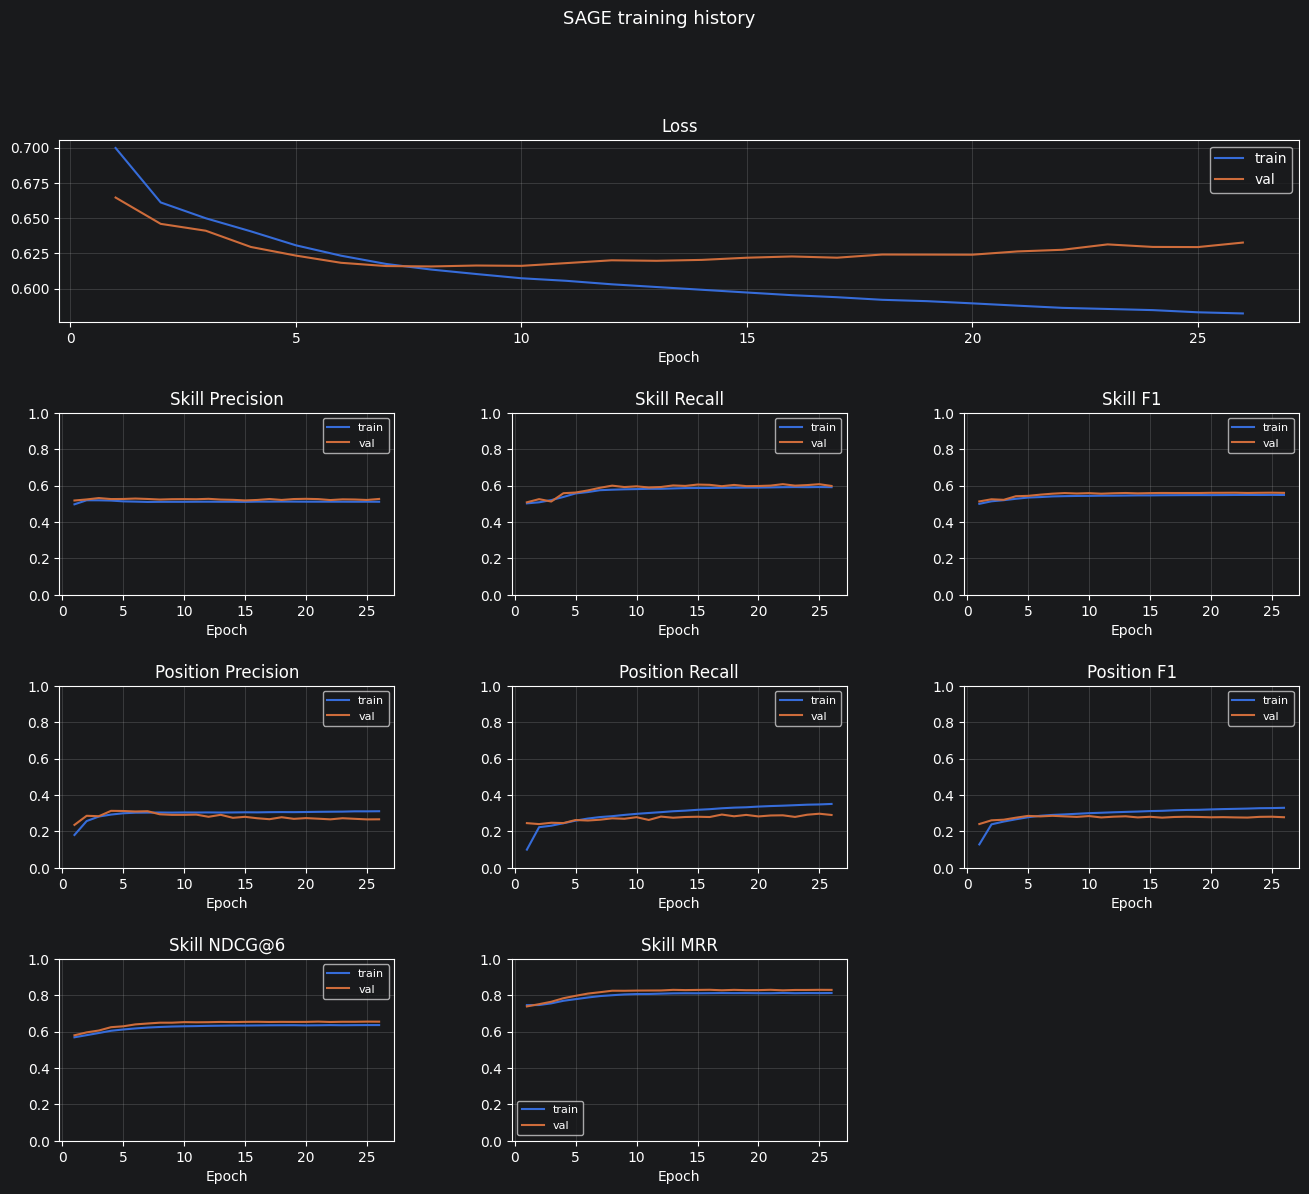

In [52]:
show_history(sage_history, "SAGE")

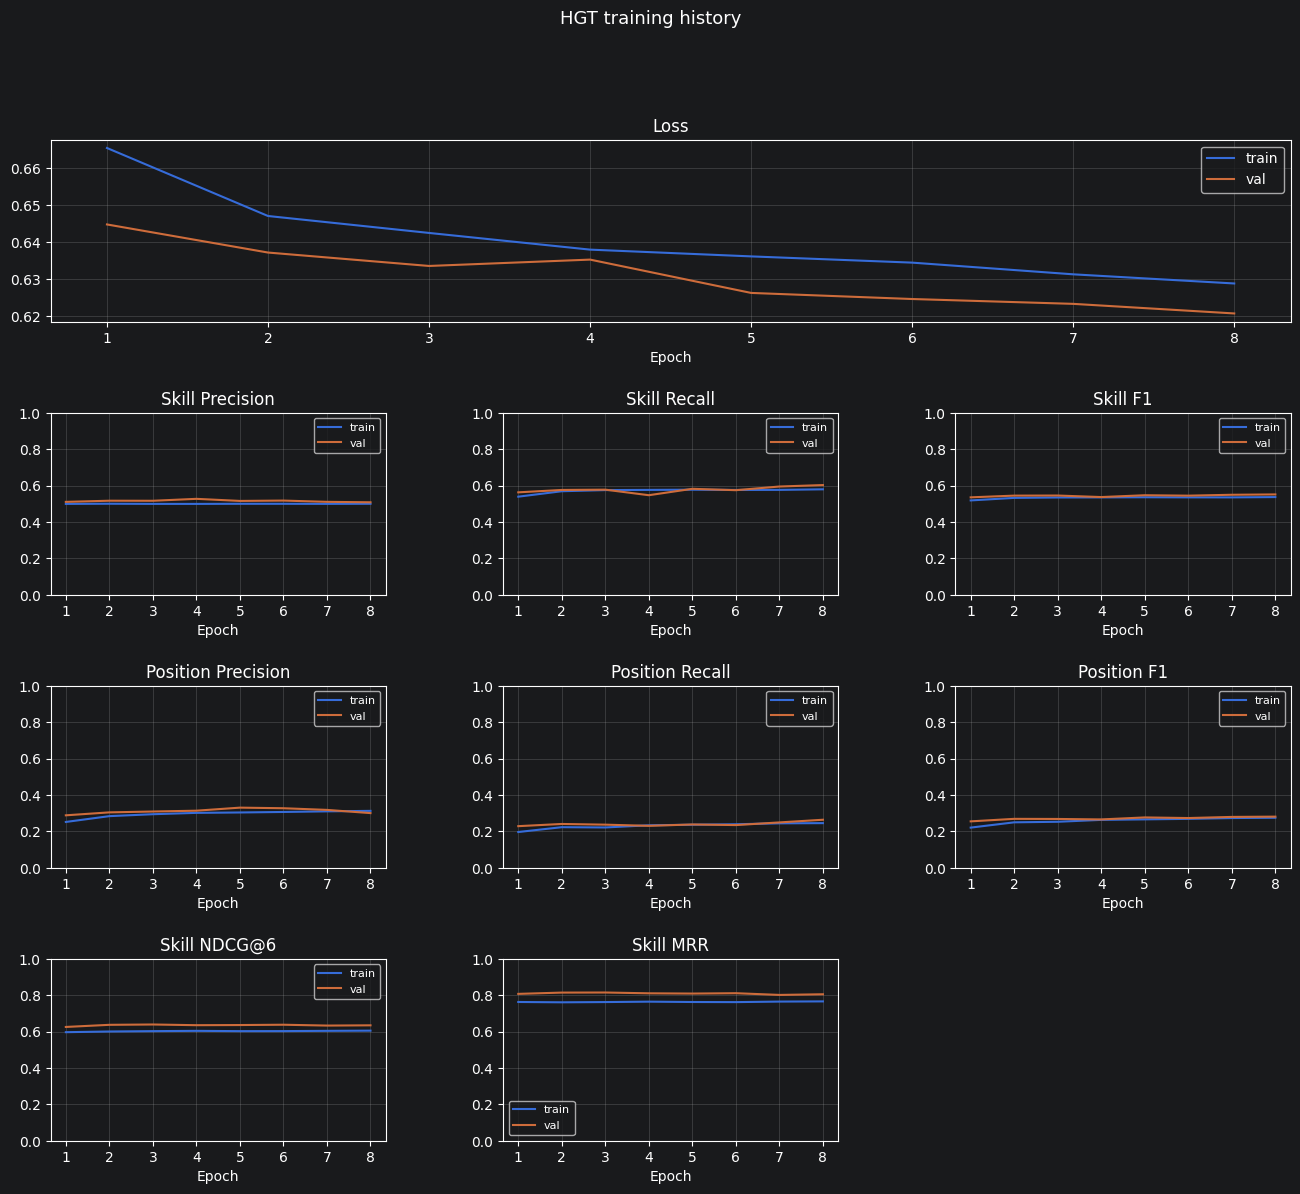

In [53]:
show_history(hgt_history, "HGT")

## 6. Inference

In [54]:
scenarios = [
    {
        "label": "Almost-complete team (3/4 members, AI hackathon)",
        "topic": "AI / Machine Learning",
        "max_team_size": 4,
        "members": [
            {"experience_years": 4.0, "position": "Machine Learning Engineer",
             "skills": ["Python", "PyTorch", "TensorFlow"]},
            {"experience_years": 2.0, "position": "Backend Developer",
             "skills": ["Python", "FastAPI", "PostgreSQL"]},
            {"experience_years": 1.5, "position": "Data Scientist",
             "skills": ["Python", "scikit-learn", "Pandas", "NumPy"]},
        ],
    },
    {
        "label": "Single person (Web hackathon)",
        "topic": "Web Development",
        "max_team_size": 4,
        "members": [
            {"experience_years": 3.0, "position": "Frontend Developer",
             "skills": ["JavaScript", "React", "TypeScript"]},
        ],
    },
]

In [55]:
def run_inference(model, name: str, scenarios: list) -> None:
    for sc in scenarios:
        missing_slots = max(1, sc["max_team_size"] - len(sc["members"]))
        kwargs = dict(
            topic=sc["topic"],
            max_team_size=sc["max_team_size"],
            members=sc["members"],
        )

        _sync()
        t0 = time.perf_counter()
        result = model.recommend(**kwargs)
        _sync()
        elapsed_ms = (time.perf_counter() - t0) * 1000

        print(f"\n{'─' * 60}")
        print(f"[{name}] {sc['label']} (missing_slots={missing_slots})")
        print(f"\tskills: {result['recommended_skills']}")
        print(f"\tpositions: {result['recommended_positions']}")
        print(f"\tinference: {elapsed_ms:.2f} ms")

### Random Forest

In [56]:
run_inference(model_rf, "Random Forest", scenarios)


────────────────────────────────────────────────────────────
[Random Forest] Almost-complete team (3/4 members, AI hackathon) (missing_slots=1)
	skills: ['Docker', 'NLP', 'Computer Vision']
	positions: ['Product Manager']
	inference: 2111.65 ms

────────────────────────────────────────────────────────────
[Random Forest] Single person (Web hackathon) (missing_slots=3)
	skills: ['Vue.js', 'Redis', 'Node.js', 'PostgreSQL', 'UI/UX Design', 'Figma', 'MongoDB', 'AWS']
	positions: ['Full Stack Developer', 'UI/UX Designer', 'Backend Developer']
	inference: 1674.94 ms


### SAGE

In [57]:
loaded_sage = TeamCompletionSAGE.from_checkpoint(
    MODEL_OUT_SAGE, hidden_dim=HIDDEN_DIM, num_layers=3, dropout=DROPOUT, device=DEVICE
)

In [58]:
run_inference(loaded_sage, "SAGE", scenarios)


────────────────────────────────────────────────────────────
[SAGE] Almost-complete team (3/4 members, AI hackathon) (missing_slots=1)
	skills: ['Docker', 'AWS', 'Technical Writing', 'Unit Testing']
	positions: ['Blockchain Developer']
	inference: 22.77 ms

────────────────────────────────────────────────────────────
[SAGE] Single person (Web hackathon) (missing_slots=3)
	skills: ['Figma', 'UI/UX Design', 'Docker', 'PostgreSQL', 'AWS', 'Redis', 'Vue.js', 'Node.js', 'MongoDB', 'Unit Testing', 'Agile / Scrum', 'Technical Writing']
	positions: ['QA Engineer', 'Blockchain Developer', 'Embedded / IoT Engineer']
	inference: 6.13 ms


### HGT

In [59]:
loaded_hgt = TeamCompletionHGT.from_checkpoint(
    MODEL_OUT_HGT, hidden_dim=HIDDEN_DIM, num_heads=4, num_layers=3, dropout=DROPOUT, device=DEVICE
)

In [60]:
run_inference(loaded_hgt, "HGT", scenarios)


────────────────────────────────────────────────────────────
[HGT] Almost-complete team (3/4 members, AI hackathon) (missing_slots=1)
	skills: ['Docker', 'Computer Vision', 'NLP', 'React']
	positions: ['AR/VR Developer']
	inference: 34.97 ms

────────────────────────────────────────────────────────────
[HGT] Single person (Web hackathon) (missing_slots=3)
	skills: ['UI/UX Design', 'Figma', 'Docker', 'PostgreSQL', 'AWS', 'Python', 'Redis', 'Technical Writing', 'Unit Testing', 'FastAPI', 'Agile / Scrum', 'Vue.js']
	positions: ['QA Engineer', 'Data Scientist', 'Product Manager']
	inference: 11.79 ms
